<a href="https://colab.research.google.com/github/sathursiyakrishnamoorthy/Data-Science-Project-Hotel-A/blob/Model-choosing-phase/Random_forest_test_imbalanced_ipynb_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Preprocessing & Partitioning

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Loading the datasets
train_raw = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-train (1).csv')
val_raw = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-validation (1).csv')

def preprocess_for_rf(df):
    df = df.copy()


    if 'Reservation_Status' in df.columns:
        df['Reservation_Status'] = df['Reservation_Status'].str.strip().str.lower()
        # Mapping: Check-in/out -> 1, Canceled -> 2, No-show -> 3
        status_map = {'check-in': 1, 'check-out': 1, 'canceled': 2, 'no-show': 3}
        df['Reservation_Status'] = df['Reservation_Status'].map(status_map)

    # Feature Engineering: Dates to LeadTime

    df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'], format='mixed')
    df['Booking_date'] = pd.to_datetime(df['Booking_date'], format='mixed')
    df['LeadTime'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

    # Categorical Encoding
    le = LabelEncoder()
    categorical_cols = ['Gender', 'Ethnicity', 'Educational_Level', 'Income',
                        'Country_region', 'Hotel_Type', 'Meal_Type', 'Deposit_type', 'Booking_channel']

    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    # Converting Yes/No to 1/0
    binary_cols = ['Visted_Previously', 'Previous_Cancellations', 'Required_Car_Parking', 'Use_Promotion']
    for col in binary_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0})


    cols_to_drop = ['Reservation-id', 'Expected_checkin', 'Expected_checkout', 'Booking_date']
    df = df.drop(columns=cols_to_drop)

    return df.fillna(0)

# Applying preprocessing
train_df = preprocess_for_rf(train_raw)
val_df = preprocess_for_rf(val_raw)

# Partitioning
X_train = train_df.drop('Reservation_Status', axis=1)
y_train = train_df['Reservation_Status']

X_val = val_df.drop('Reservation_Status', axis=1)
y_val = val_df['Reservation_Status']

print("Step 1 Complete: Data is cleaned, encoded, and partitioned.")
print(f"Training shapes: {X_train.shape}, Validation shapes: {X_val.shape}")

Step 1 Complete: Data is cleaned, encoded, and partitioned.
Training shapes: (27499, 20), Validation shapes: (2749, 20)


Building the Random Forest Model

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Re-defining preprocess_for_rf function and re-load data to ensure X_train and y_train are available
def preprocess_for_rf(df):
    df = df.copy()


    if 'Reservation_Status' in df.columns:
        df['Reservation_Status'] = df['Reservation_Status'].str.strip().str.lower()

        status_map = {'check-in': 1, 'check-out': 1, 'canceled': 2, 'no-show': 3}
        df['Reservation_Status'] = df['Reservation_Status'].map(status_map)

    # Feature Engineering: Dates to LeadTime

    df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'], format='mixed')
    df['Booking_date'] = pd.to_datetime(df['Booking_date'], format='mixed')
    df['LeadTime'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

    # Categorical Encoding
    le = LabelEncoder()
    categorical_cols = ['Gender', 'Ethnicity', 'Educational_Level', 'Income',
                        'Country_region', 'Hotel_Type', 'Meal_Type', 'Deposit_type', 'Booking_channel']

    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    # Converting Yes/No to 1/0
    binary_cols = ['Visted_Previously', 'Previous_Cancellations', 'Required_Car_Parking', 'Use_Promotion']
    for col in binary_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0})


    cols_to_drop = ['Reservation-id', 'Expected_checkin', 'Expected_checkout', 'Booking_date']
    df = df.drop(columns=cols_to_drop)

    return df.fillna(0)

# Loading the datasets
train_raw = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-train (1).csv')
val_raw = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-validation (1).csv')

# Applying preprocessing
train_df = preprocess_for_rf(train_raw)
val_df = preprocess_for_rf(val_raw)

# Partitioning
X_train = train_df.drop('Reservation_Status', axis=1)
y_train = train_df['Reservation_Status']

X_val = val_df.drop('Reservation_Status', axis=1)
y_val = val_df['Reservation_Status']

# Initialising the Random Forest

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight='balanced',
    random_state=42)

# Building the model
print("Building the model... Please wait.")
rf_model.fit(X_train, y_train)

print("Step 2 Complete: The Random Forest model has been built and trained.")

Building the model... Please wait.
Step 2 Complete: The Random Forest model has been built and trained.


In [4]:
def boost_accuracy_preprocess(df):
    # Converting to dates
    df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
    df['Booking_date'] = pd.to_datetime(df['Booking_date'])
    df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])

    # Creating the "Gold Mine" Features
    # Lead Time
    df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

    # Stay Duration
    df['Stay_Nights'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

    # SELECTING ONLY THE BEST COLUMNS
    important_cols = [
        'Lead_Time', 'Stay_Nights', 'Deposit_type', 'Previous_Cancellations',
        'Booking_channel', 'Required_Car_Parking', 'Room_Rate',
        'Adults', 'Children', 'Visted_Previously', 'Discount_Rate'
    ]


    cols_to_keep = [c for c in important_cols if c in df.columns]
    df_boosted = df[cols_to_keep].copy()

    # HANDLING CATEGORICAL DATA

    df_boosted = pd.get_dummies(df_boosted)

    return df_boosted

Evaluate Model

Overall Model Accuracy: 0.5617

Classification Report:
              precision    recall  f1-score   support

Check-In/Out       0.59      0.92      0.72      1610
    Canceled       0.30      0.09      0.14       741
     No-Show       0.19      0.01      0.01       398

    accuracy                           0.56      2749
   macro avg       0.36      0.34      0.29      2749
weighted avg       0.45      0.56      0.46      2749



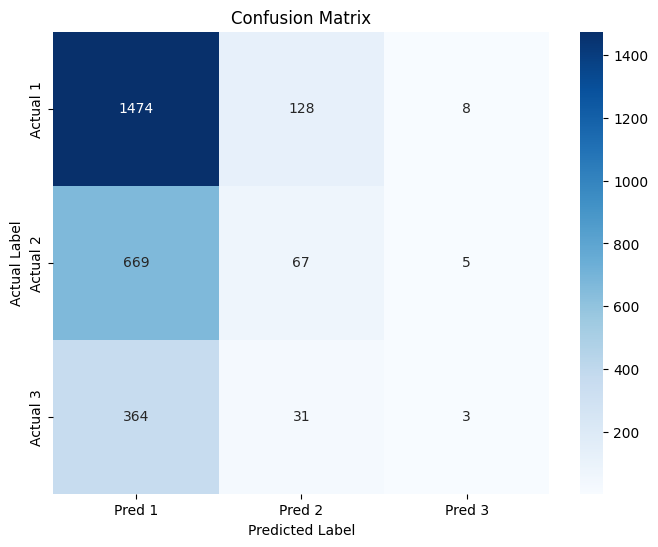

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Making predictions on the Validation set
y_pred = rf_model.predict(X_val)

# Calculating Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Model Accuracy: {accuracy:.4f}")

# Generating Classification Report
# This directly addresses the metrics on Slide 27 of your lecture
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Check-In/Out', 'Canceled', 'No-Show']))

# Generating Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 1', 'Pred 2', 'Pred 3'],
            yticklabels=['Actual 1', 'Actual 2', 'Actual 3'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

Final Testing (Generating Predictions for the Test Set)

In [6]:
# Loading the hidden Test set
test_raw = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-test (1).csv')



test_df = preprocess_for_rf(test_raw)

# Generating Predictions

test_predictions = rf_model.predict(test_df)

# Preparing the Final Output

reverse_map = {1: 'Check-In', 2: 'Canceled', 3: 'No-Show'}
test_raw['Predicted_Reservation_Status'] = pd.Series(test_predictions).map(reverse_map)


test_raw.to_csv('Hotel-A-Final-Predictions.csv', index=False)

print("Step 4 Complete: Final predictions have been generated!")
print("The file 'Hotel-A-Final-Predictions.csv' is ready for your report.")

Step 4 Complete: Final predictions have been generated!
The file 'Hotel-A-Final-Predictions.csv' is ready for your report.


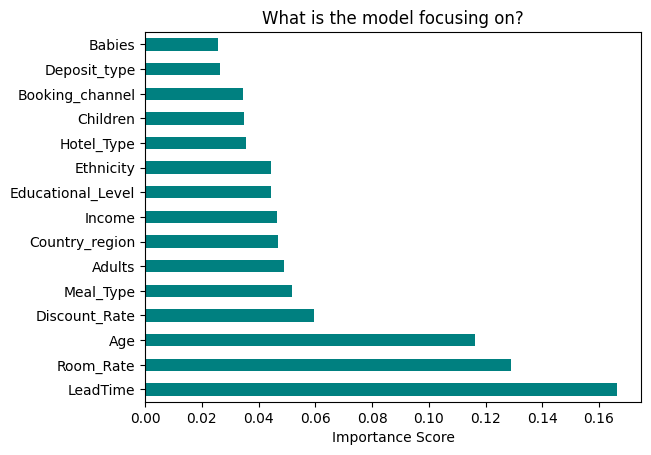

In [7]:
import matplotlib.pyplot as plt


importances = rf_model.feature_importances_
feature_names = X_val.columns
feat_importances = pd.Series(importances, index=feature_names)


feat_importances.nlargest(15).plot(kind='barh', color='teal')
plt.title("What is the model focusing on?")
plt.xlabel("Importance Score")
plt.show()